# *****Player Classification Model*****

**Tujuan:** Membuat model KNN dengan memenuhi syarat:
- Tidak *underfit* maupun *overfit*
- *Robust* terhadap variasi data dan *random seed*
- Kemampuan generalisasi yang baik (gap train-val < 5%)

**Output:** File `Player_Classifier.pkl` kompatibel dengan `PlayerMLEngine` di `Sudoku.py`.

| Label | Tipe Pemain | Karakteristik |
|-------|-------------|---------------|
| 0 | `Speedrunner` | Cepat, akurat, jarang hint |
| 1 | `Careful` | Lambat, sangat akurat, jarang hint |
| 2 | `Learner` | Sedang, error moderat, hint moderat |
| 3 | `Struggling` | Banyak error, banyak hint, jarang selesai |
| 4 | `Inconsistent` | Variansi tinggi, metrik campuran |

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import (
    StratifiedKFold, GridSearchCV, cross_val_score,
    learning_curve, train_test_split
)
from sklearn.metrics import (
    classification_report, confusion_matrix,
    ConfusionMatrixDisplay, accuracy_score, accuracy_score
)
from sklearn.pipeline import Pipeline
from sklearn.inspection import permutation_importance
import pickle
import warnings

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", palette="deep")
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

PLAYER_TYPES  = ["Speedrunner", "Careful", "Learner", "Struggling", "Inconsistent"]
FEATURE_NAMES = [
    "avg_time_per_cell", "error_rate", "hint_rate",
    "completion_rate",   "near_miss_rate", "guessing_rate"
]
TYPE_COLORS   = ["#FFD700", "#7EE787", "#58A6FF", "#FF7B7B", "#F0883E"]

print(f"Player types   : {PLAYER_TYPES}")
print(f"Feature names  : {FEATURE_NAMES}")

Player types   : ['Speedrunner', 'Careful', 'Learner', 'Struggling', 'Inconsistent']
Feature names  : ['avg_time_per_cell', 'error_rate', 'hint_rate', 'completion_rate', 'near_miss_rate', 'guessing_rate']


## 1. ***Synthetic Data Generation***

Setiap kelas di-*generate* **500 sampel** (total 2.500) dari distribusi *uniform* dengan Gaussian *noise* terkontrol.
Penambahan *noise* penting agar:
- Ada *overlap* realistis antar kelas (terutama `Inconsistent` vs `Learner`)
- Model tidak *overfit* pada batas kelas yang terlalu tajam
- Sesuai kondisi data nyata yang tidak sempurna

Semua nilai di-*clip* ke range valid setelah penambahan *noise*.

In [2]:
def generate_class(n, specs, seed):
    """
    Generate n samples untuk satu kelas.
    specs: list of (lo, hi, noise_std) - satu tuple per fitur.
    """
    rng = np.random.default_rng(seed)
    cols = []
    for lo, hi, noise_std in specs:
        base = rng.uniform(lo, hi, n)
        if noise_std > 0:
            base += rng.normal(0, noise_std, n)
        cols.append(base)
    return np.column_stack(cols)

N = 500  # sampel per kelas

# Setiap baris: (lo, hi, noise_std) untuk 6 fitur:
#   avg_time_per_cell | error_rate | hint_rate
#   completion_rate   | near_miss_rate | guessing_rate

specs_sr = [  # Speedrunner: cepat, akurat
    (0.8,  5.0, 0.40), (0.000, 0.050, 0.008),
    (0.000, 0.050, 0.008), (0.88,  1.00, 0.025),
    (0.10, 0.50, 0.040), (0.00, 0.20, 0.025)
]
specs_ca = [  # Careful: lambat, akurat
    (15.0, 32.0, 2.00), (0.000, 0.080, 0.010),
    (0.000, 0.070, 0.010), (0.85,  1.00, 0.025),
    (0.30, 0.75, 0.050), (0.00, 0.15, 0.020)
]
specs_ln = [  # Learner: moderat
    (6.0,  14.0, 1.20), (0.100, 0.250, 0.020),
    (0.100, 0.250, 0.020), (0.55,  0.82, 0.040),
    (0.40, 0.72, 0.050), (0.20, 0.45, 0.035)
]
specs_st = [  # Struggling: banyak error & hint
    (10.0, 35.0, 3.00), (0.300, 0.650, 0.040),
    (0.350, 0.700, 0.040), (0.05,  0.40, 0.040),
    (0.20, 0.55, 0.050), (0.60, 0.95, 0.035)
]
specs_in = [  # Inconsistent: variansi tinggi, overlap Learner+Struggling
    (5.0,  18.0, 2.50), (0.150, 0.380, 0.050),
    (0.100, 0.320, 0.040), (0.40,  0.68, 0.060),
    (0.50, 0.82, 0.055), (0.40, 0.68, 0.050)
]

X_parts = [
    generate_class(N, specs_sr, seed=1),
    generate_class(N, specs_ca, seed=2),
    generate_class(N, specs_ln, seed=3),
    generate_class(N, specs_st, seed=4),
    generate_class(N, specs_in, seed=5),
]
X = np.vstack(X_parts)
y = np.array([i for i in range(5) for _ in range(N)])

# Clip ke range valid
CLIP = [
    (0.3,  45.0),   # avg_time_per_cell (detik per sel)
    (0.0,   1.0),   # error_rate
    (0.0,   1.0),   # hint_rate
    (0.0,   1.0),   # completion_rate
    (0.0,   1.0),   # near_miss_rate
    (0.0,   1.0),   # guessing_rate
]
for i, (lo, hi) in enumerate(CLIP):
    X[:, i] = np.clip(X[:, i], lo, hi)

df = pd.DataFrame(X, columns=FEATURE_NAMES)
df["player_type"] = [PLAYER_TYPES[i] for i in y]

print(f"Dataset shape : {X.shape}  ({X.shape[0]} sampel, {X.shape[1]} fitur)")
print(f"Kelas         : {N} sampel x {len(PLAYER_TYPES)} kelas = {X.shape[0]} total")
print(f"Class balance : {np.bincount(y)}  (balanced)")

Dataset shape : (2500, 6)  (2500 sampel, 6 fitur)
Kelas         : 500 sampel x 5 kelas = 2500 total
Class balance : [500 500 500 500 500]  (balanced)


In [3]:
# Statistik per kelas : cek apakah distribusi sudah representatif
stats = df.groupby("player_type")[FEATURE_NAMES].agg(["mean", "std"]).round(3)
print("=== Statistik Mean per Kelas ===")
print(df.groupby("player_type")[FEATURE_NAMES].mean().round(3).to_string())
print()
print("=== Statistik Std per Kelas ===")
print(df.groupby("player_type")[FEATURE_NAMES].std().round(3).to_string())

=== Statistik Mean per Kelas ===
              avg_time_per_cell  error_rate  hint_rate  completion_rate  near_miss_rate  guessing_rate
player_type                                                                                           
Careful                  23.402       0.041      0.036            0.923           0.535          0.078
Inconsistent             11.337       0.269      0.212            0.539           0.654          0.534
Learner                  10.014       0.177      0.173            0.686           0.565          0.320
Speedrunner               2.840       0.026      0.025            0.938           0.302          0.102
Struggling               23.345       0.472      0.530            0.228           0.373          0.777

=== Statistik Std per Kelas ===
              avg_time_per_cell  error_rate  hint_rate  completion_rate  near_miss_rate  guessing_rate
player_type                                                                                           
Careful

## 2. ***Exploratory Data Analysis* (EDA)**

Visualisasi distribusi setiap fitur per kelas dan hubungan antar fitur.
Dari sini kita bisa melihat:
- Fitur mana yang paling membedakan kelas
- Seberapa besar *overlap* antar kelas (terutama `Inconsistent`)
- Apakah *scaling* diperlukan (ya, karena `avg_time_per_cell` range ~0–35 vs rate ~0–1)

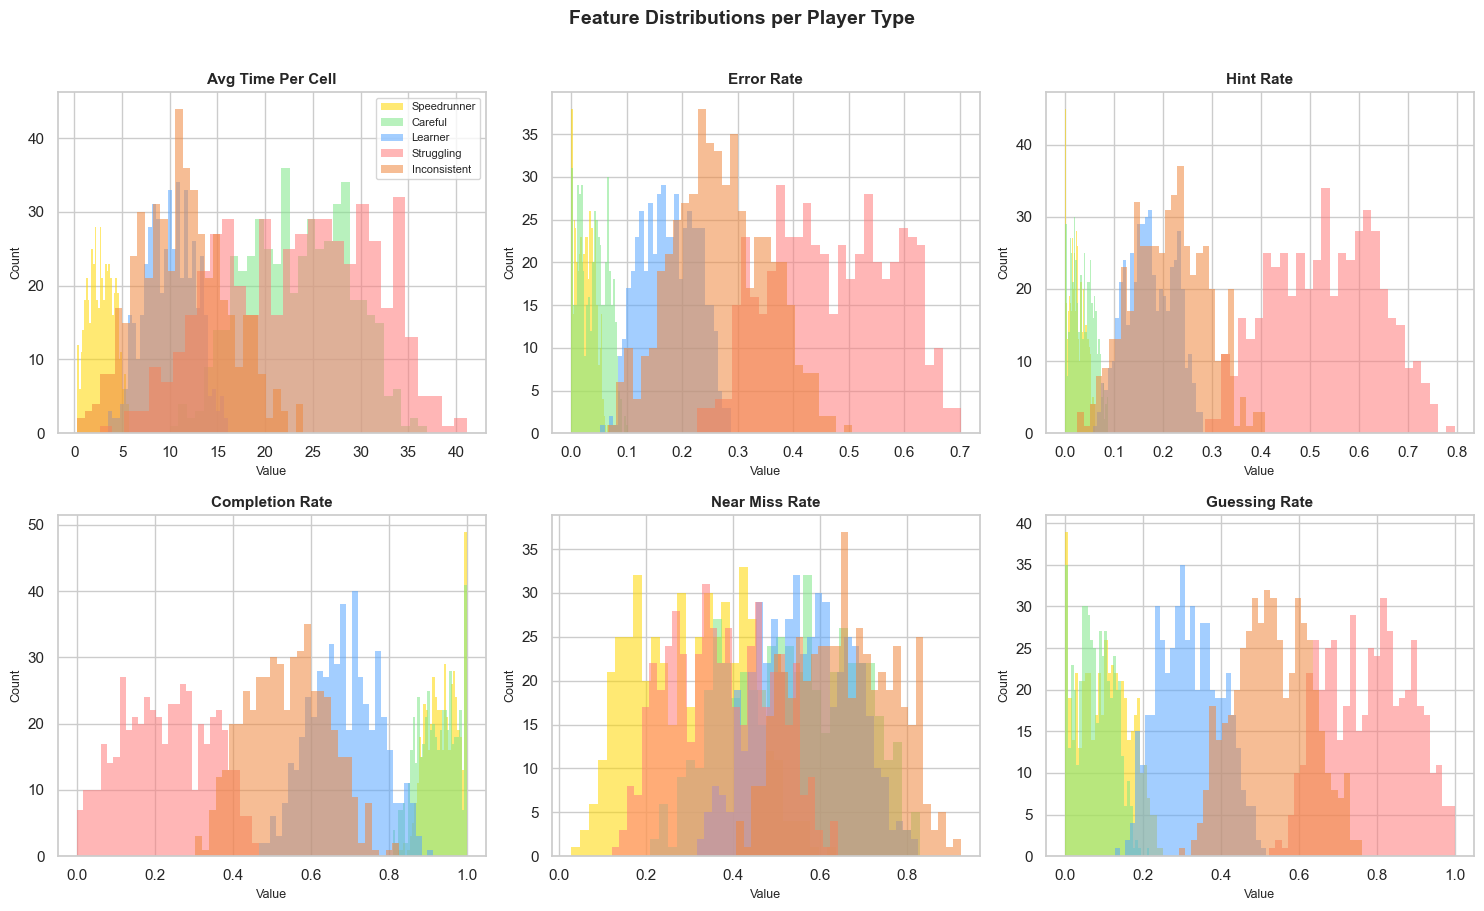

Catatan: avg_time_per_cell adalah fitur paling diskriminatif (Speedrunner vs Careful)
         error_rate + hint_rate membedakan Struggling dari kelas lain
         Inconsistent overlap signifikan dengan Learner & Struggling


In [4]:
fig, axes = plt.subplots(2, 3, figsize=(15, 9))
axes = axes.flatten()

for i, (feat, ax) in enumerate(zip(FEATURE_NAMES, axes)):
    for ptype, color in zip(PLAYER_TYPES, TYPE_COLORS):
        data = df[df["player_type"] == ptype][feat]
        ax.hist(data, bins=30, alpha=0.55, color=color,
                label=ptype, edgecolor="none")
    ax.set_title(feat.replace("_", " ").title(), fontsize=11, fontweight="bold")
    ax.set_xlabel("Value", fontsize=9)
    ax.set_ylabel("Count", fontsize=9)
    if i == 0:
        ax.legend(fontsize=8, loc="upper right")

plt.suptitle("Feature Distributions per Player Type", fontsize=14, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()
print("Catatan: avg_time_per_cell adalah fitur paling diskriminatif (Speedrunner vs Careful)")
print("         error_rate + hint_rate membedakan Struggling dari kelas lain")
print("         Inconsistent overlap signifikan dengan Learner & Struggling")

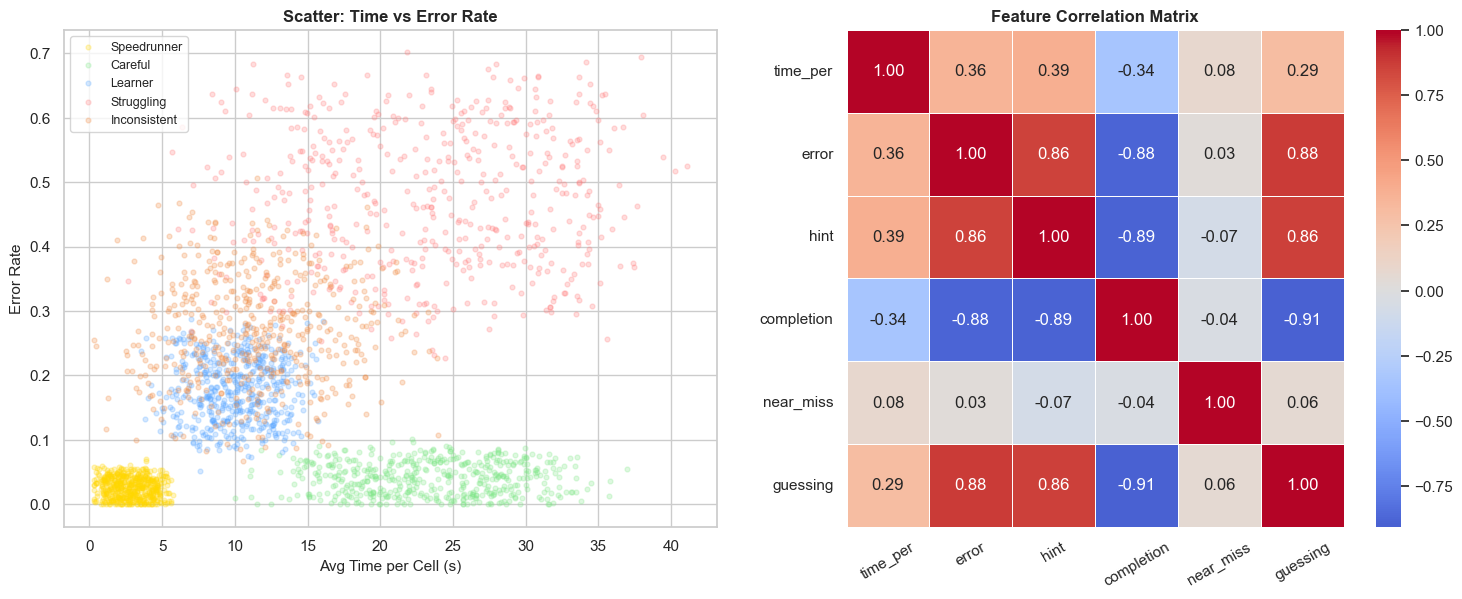

Korelasi kuat (|r| > 0.4):
  error_rate                <-> hint_rate           : r = 0.857
  error_rate                <-> completion_rate     : r = -0.881
  error_rate                <-> guessing_rate       : r = 0.878
  hint_rate                 <-> completion_rate     : r = -0.886
  hint_rate                 <-> guessing_rate       : r = 0.863
  completion_rate           <-> guessing_rate       : r = -0.906


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Scatter: 2 fitur paling diskriminatif
ax = axes[0]
for ptype, color in zip(PLAYER_TYPES, TYPE_COLORS):
    mask = df["player_type"] == ptype
    ax.scatter(
        df[mask]["avg_time_per_cell"],
        df[mask]["error_rate"],
        alpha=0.25, color=color, s=12, label=ptype
    )
ax.set_xlabel("Avg Time per Cell (s)", fontsize=11)
ax.set_ylabel("Error Rate", fontsize=11)
ax.set_title("Scatter: Time vs Error Rate", fontsize=12, fontweight="bold")
ax.legend(fontsize=9)

# Correlation heatmap (semua fitur)
corr = df[FEATURE_NAMES].corr()
mask = np.triu(np.ones_like(corr, dtype=bool), k=1)
sns.heatmap(
    corr, annot=True, fmt=".2f", cmap="coolwarm",
    ax=axes[1], center=0, square=True,
    xticklabels=[f.replace("avg_","").replace("_rate","").replace("_cell","") for f in FEATURE_NAMES],
    yticklabels=[f.replace("avg_","").replace("_rate","").replace("_cell","") for f in FEATURE_NAMES],
    linewidths=0.5
)
axes[1].set_title("Feature Correlation Matrix", fontsize=12, fontweight="bold")
axes[1].tick_params(axis="x", rotation=30)
axes[1].tick_params(axis="y", rotation=0)

plt.tight_layout()
plt.show()

print("Korelasi kuat (|r| > 0.4):")
for i in range(len(FEATURE_NAMES)):
    for j in range(i+1, len(FEATURE_NAMES)):
        r = corr.iloc[i, j]
        if abs(r) > 0.4:
            print(f"  {FEATURE_NAMES[i]:25s} <-> {FEATURE_NAMES[j]:20s}: r = {r:.3f}")

## 3. ***Preprocessing & Train/Test Split***

- **Stratified split** 80/20 : menjamin distribusi kelas sama di train dan test
- `StandardScaler` akan di-fit HANYA pada data train (di dalam pipeline GridSearchCV) agar tidak terjadi *data leakage* ke *validation/test set*
- Scaling wajib untuk KNN karena jarak *Euclidean* sensitif terhadap skala fitur

In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=RANDOM_SEED,
    stratify=y          # jamin distribusi kelas seimbang
)

print(f"Train set : {X_train.shape[0]} sampel")
print(f"Test  set : {X_test.shape[0]} sampel")
print()
print("Distribusi kelas (train):")
for i, name in enumerate(PLAYER_TYPES):
    cnt = np.sum(y_train == i)
    print(f"  [{i}] {name:<15}: {cnt} ({cnt/len(y_train)*100:.1f}%)")
print()
print("Distribusi kelas (test):")
for i, name in enumerate(PLAYER_TYPES):
    cnt = np.sum(y_test == i)
    print(f"  [{i}] {name:<15}: {cnt} ({cnt/len(y_test)*100:.1f}%)")

Train set : 2000 sampel
Test  set : 500 sampel

Distribusi kelas (train):
  [0] Speedrunner    : 400 (20.0%)
  [1] Careful        : 400 (20.0%)
  [2] Learner        : 400 (20.0%)
  [3] Struggling     : 400 (20.0%)
  [4] Inconsistent   : 400 (20.0%)

Distribusi kelas (test):
  [0] Speedrunner    : 100 (20.0%)
  [1] Careful        : 100 (20.0%)
  [2] Learner        : 100 (20.0%)
  [3] Struggling     : 100 (20.0%)
  [4] Inconsistent   : 100 (20.0%)


## 4. ***Baseline Model***

In [7]:
# Fit scaler pada train saja, sama seperti produksi
scaler_base = StandardScaler()
X_tr_sc = scaler_base.fit_transform(X_train)
X_te_sc = scaler_base.transform(X_test)

knn_base = KNeighborsClassifier(n_neighbors=3, metric="euclidean")
knn_base.fit(X_tr_sc, y_train)

base_train_acc = knn_base.score(X_tr_sc, y_train)
base_test_acc  = knn_base.score(X_te_sc,  y_test)

cv_base = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_SEED)
cv_base_scores = cross_val_score(
    KNeighborsClassifier(n_neighbors=3, metric="euclidean"),
    X_tr_sc, y_train,
    cv=cv_base, scoring="accuracy"
)

gap = base_train_acc - base_test_acc
print("=" * 45)
print("BASELINE (k=3, euclidean, uniform weights)")
print("=" * 45)
print(f"Train Accuracy   : {base_train_acc:.4f}")
print(f"Test  Accuracy   : {base_test_acc:.4f}")
print(f"Gap (train-test) : {gap:.4f}", end="")
print(" <- OVERFIT" if gap > 0.05 else " <- OK")
print(f"5-Fold CV Acc     : {cv_base_scores.mean():.4f} +/- {cv_base_scores.std():.4f}")
print()
print("Classification Report (Baseline):")
y_pred_base = knn_base.predict(X_te_sc)
print(classification_report(y_test, y_pred_base, target_names=PLAYER_TYPES, digits=4))

BASELINE (k=3, euclidean, uniform weights)
Train Accuracy   : 0.9890
Test  Accuracy   : 0.9860
Gap (train-test) : 0.0030 <- OK
5-Fold CV Acc     : 0.9785 +/- 0.0066

Classification Report (Baseline):
              precision    recall  f1-score   support

 Speedrunner     1.0000    1.0000    1.0000       100
     Careful     1.0000    1.0000    1.0000       100
     Learner     0.9429    0.9900    0.9659       100
  Struggling     1.0000    1.0000    1.0000       100
Inconsistent     0.9895    0.9400    0.9641       100

    accuracy                         0.9860       500
   macro avg     0.9865    0.9860    0.9860       500
weighted avg     0.9865    0.9860    0.9860       500



## 5. ***Hyperparameter Tuning menggunakan `GridSearchCV`***

**Pipeline** digunakan agar `StandardScaler` ikut ter-cross-validate → **tidak ada *data leakage***.

***Search space*:**
| Parameter | Nilai |
|-----------|-------|
| `n_neighbors` | 3, 5, 7, 9, 11, 13, 15, 17, 19, 21 |
| `metric` | euclidean, manhattan |
| `weights` | uniform, distance |

**Scoring:** `accuracy` : lebih fair dari *accuracy* untuk multi-class  
**CV:** `StratifiedKFold(n_splits=5)` : menjaga distribusi kelas di setiap fold

In [8]:
pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("knn",    KNeighborsClassifier())
])

param_grid = {
    "knn__n_neighbors": [3, 5, 7, 9, 11, 13, 15, 17, 19, 21],
    "knn__metric":      ["euclidean", "manhattan"],
    "knn__weights":     ["uniform", "distance"],
}

cv_strat = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_SEED)

grid_search = GridSearchCV(
    pipe,
    param_grid,
    cv=cv_strat,
    scoring="accuracy",
    n_jobs=-1,
    verbose=0,
    refit=True,           # otomatis refit dengan best params di seluruh train set
    return_train_score=True
)
grid_search.fit(X_train, y_train)

best_p      = grid_search.best_params_
best_cv_acc  = grid_search.best_score_
tuned_test  = grid_search.best_estimator_.score(X_test, y_test)
tuned_train = grid_search.best_estimator_.score(X_train, y_train)

print("=" * 45)
print("GRID SEARCH RESULTS")
print("=" * 45)
print(f"Best params      : {best_p}")
print(f"Best CV Accuracy  : {best_cv_acc:.4f}")
print(f"Train Accuracy   : {tuned_train:.4f}")
print(f"Test  Accuracy   : {tuned_test:.4f}")
print(f"Gap (train-test) : {tuned_train - tuned_test:.4f}",
      "<- OVERFIT" if (tuned_train - tuned_test) > 0.05 else "<- OK")
print()
print(f"Total kombinasi  : {len(grid_search.cv_results_['params'])}")
print(f"Total CV fits    : {len(grid_search.cv_results_['params']) * 5}")

# Top 5 kombinasi
results_df = pd.DataFrame(grid_search.cv_results_)
top5 = results_df.sort_values("mean_test_score", ascending=False)[
    ["param_knn__n_neighbors", "param_knn__metric", "param_knn__weights",
     "mean_test_score", "std_test_score"]
].head(5).rename(columns={
    "param_knn__n_neighbors": "k",
    "param_knn__metric": "metric",
    "param_knn__weights": "weights",
    "mean_test_score": "CV Acc",
    "std_test_score": "std"
})
print()
print("Top 5 kombinasi parameter:")
print(top5.reset_index(drop=True).to_string(index=False))

GRID SEARCH RESULTS
Best params      : {'knn__metric': 'euclidean', 'knn__n_neighbors': 15, 'knn__weights': 'uniform'}
Best CV Accuracy  : 0.9805
Train Accuracy   : 0.9790
Test  Accuracy   : 0.9900
Gap (train-test) : -0.0110 <- OK

Total kombinasi  : 40
Total CV fits    : 200

Top 5 kombinasi parameter:
 k    metric  weights  CV Acc      std
15 euclidean  uniform  0.9805 0.004301
 9 manhattan  uniform  0.9800 0.005477
15 euclidean distance  0.9800 0.004183
19 euclidean  uniform  0.9800 0.006519
17 euclidean  uniform  0.9795 0.006205


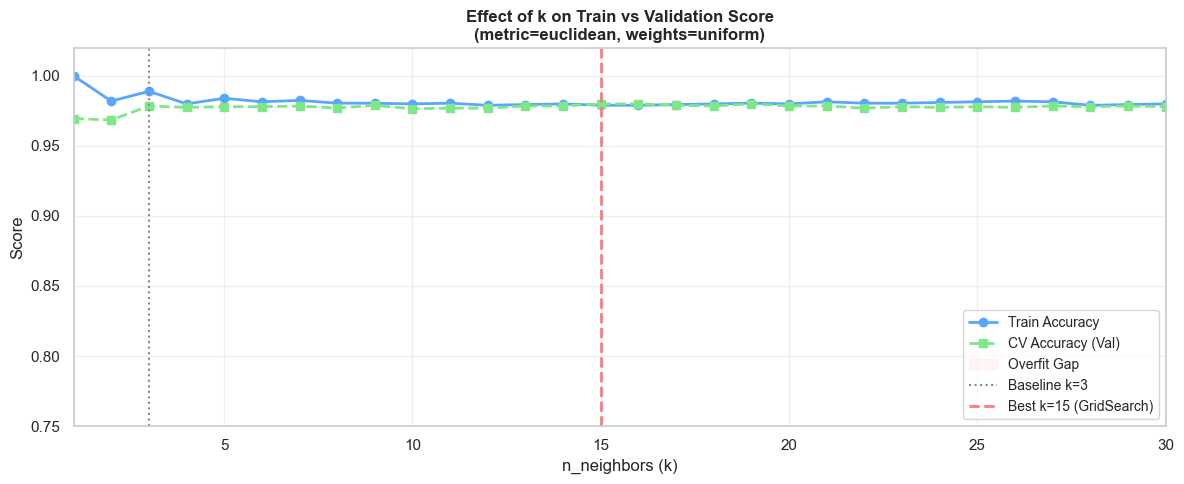

k dengan CV Acc tertinggi  : k = 15  (Acc = 0.9800)
k = 3 (baseline) CV Acc  : 0.9785
k = 3 (baseline) gap     : 0.0105
k = 15 gap         : -0.0010


In [9]:
# Visualisasi efek nilai k terhadap train accuracy dan CV validation
# Gunakan metric + weights dari hasil best GridSearch
best_metric  = best_p["knn__metric"]
best_weights = best_p["knn__weights"]
best_k       = best_p["knn__n_neighbors"]

scaler_sweep = StandardScaler()
X_tr_sw = scaler_sweep.fit_transform(X_train)
X_te_sw = scaler_sweep.transform(X_test)

k_range = range(1, 31)
train_accs, val_accs = [], []

for k in k_range:
    m = KNeighborsClassifier(n_neighbors=k, metric=best_metric, weights=best_weights)
    m.fit(X_tr_sw, y_train)
    train_accs.append(m.score(X_tr_sw, y_train))
    cv_sc = cross_val_score(
        m, X_tr_sw, y_train,
        cv=StratifiedKFold(5, shuffle=True, random_state=RANDOM_SEED),
        scoring="accuracy"
    )
    val_accs.append(cv_sc.mean())

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(k_range, train_accs, "o-",  color="#58A6FF", lw=2,   label="Train Accuracy")
ax.plot(k_range, val_accs,   "s--",  color="#7EE787", lw=2,   label="CV Accuracy (Val)")
ax.fill_between(k_range,
                [t - v for t, v in zip(train_accs, val_accs)],
                0,
                alpha=0.07, color="#FF7B7B", label="Overfit Gap")
ax.axvline(x=3,       color="#888888",  linestyle=":",  lw=1.5, label="Baseline k=3")
ax.axvline(x=best_k,  color="#FF7B7B",  linestyle="--", lw=2,   label=f"Best k={best_k} (GridSearch)")
ax.set_xlabel("n_neighbors (k)", fontsize=12)
ax.set_ylabel("Score", fontsize=12)
ax.set_title(
    f"Effect of k on Train vs Validation Score\n"
    f"(metric={best_metric}, weights={best_weights})",
    fontsize=12, fontweight="bold"
)
ax.legend(fontsize=10)
ax.set_xlim(1, 30)
ax.set_ylim(0.75, 1.02)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

best_val_k = k_range[val_accs.index(max(val_accs))]
print(f"k dengan CV Acc tertinggi  : k = {best_val_k}  (Acc = {max(val_accs):.4f})")
print(f"k = 3 (baseline) CV Acc  : {val_accs[2]:.4f}")
print(f"k = 3 (baseline) gap     : {train_accs[2] - val_accs[2]:.4f}")
print(f"k = {best_k} gap         : {train_accs[best_k-1] - val_accs[best_k-1]:.4f}")

## 6. ***Generalization Analysis - Learning Curves***

***Learning curve*** menunjukkan bagaimana performa model berubah seiring bertambahnya data training.

- **Gejala underfit:** *Training score* RENDAH, keduanya konvergen di nilai rendah
- **Gejala overfit:** *Training score* TINGGI, *validation score* JAUH lebih rendah (gap besar)
- **Model baik:** Keduanya konvergen ke nilai tinggi dengan gap < 5%

Shade area = ± 1 standar deviasi antar fold (menunjukkan stabilitas).

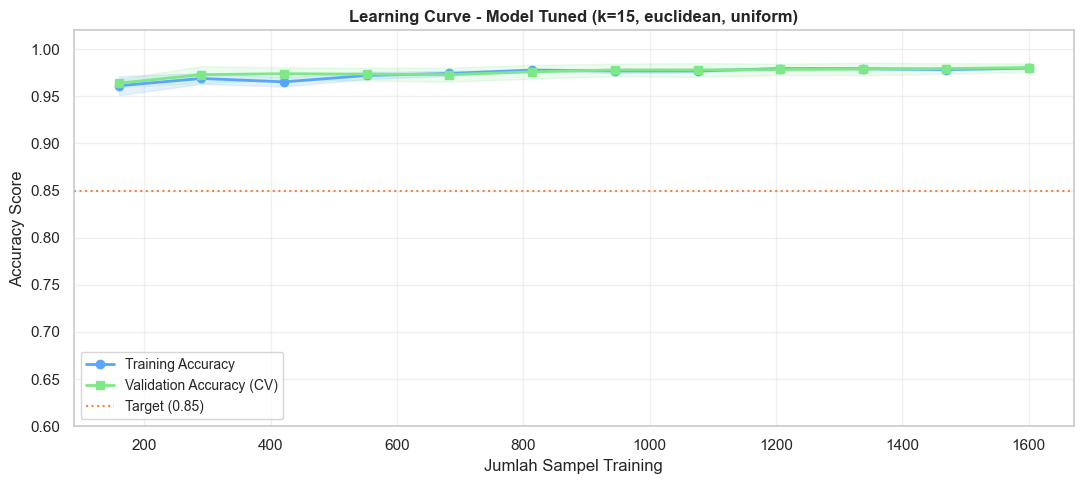

Training Acc (akhir)   : 0.9800 +/- 0.0010
Validation Acc (akhir) : 0.9805 +/- 0.0043
Gap                   : -0.0005

DIAGNOSIS: Generalisasi sangat baik (gap < 3%)


In [10]:
best_pipe = grid_search.best_estimator_

train_sizes, train_sc, val_sc = learning_curve(
    best_pipe,
    X_train, y_train,
    cv=StratifiedKFold(5, shuffle=True, random_state=RANDOM_SEED),
    train_sizes=np.linspace(0.10, 1.0, 12),
    scoring="accuracy",
    n_jobs=-1
)

tr_mean = train_sc.mean(axis=1)
tr_std  = train_sc.std(axis=1)
va_mean = val_sc.mean(axis=1)
va_std  = val_sc.std(axis=1)

fig, ax = plt.subplots(figsize=(11, 5))
ax.plot(train_sizes, tr_mean, "o-", color="#58A6FF", lw=2, label="Training Accuracy")
ax.fill_between(train_sizes, tr_mean - tr_std, tr_mean + tr_std, alpha=0.15, color="#58A6FF")
ax.plot(train_sizes, va_mean, "s-", color="#7EE787", lw=2, label="Validation Accuracy (CV)")
ax.fill_between(train_sizes, va_mean - va_std, va_mean + va_std, alpha=0.15, color="#7EE787")
ax.axhline(y=0.85, color="#F0883E", linestyle=":", lw=1.5, label="Target (0.85)")
ax.set_xlabel("Jumlah Sampel Training", fontsize=12)
ax.set_ylabel("Accuracy Score", fontsize=12)
ax.set_title(
    f"Learning Curve - Model Tuned "
    f"(k={best_k}, {best_metric}, {best_weights})",
    fontsize=12, fontweight="bold"
)
ax.legend(fontsize=10)
ax.set_ylim(0.60, 1.02)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

final_gap = tr_mean[-1] - va_mean[-1]
print(f"Training Acc (akhir)   : {tr_mean[-1]:.4f} +/- {tr_std[-1]:.4f}")
print(f"Validation Acc (akhir) : {va_mean[-1]:.4f} +/- {va_std[-1]:.4f}")
print(f"Gap                   : {final_gap:.4f}")
print()
if final_gap < 0.03:
    print("DIAGNOSIS: Generalisasi sangat baik (gap < 3%)")
elif final_gap < 0.05:
    print("DIAGNOSIS: Generalisasi baik (gap < 5%)")
elif final_gap < 0.10:
    print("DIAGNOSIS: Overfit ringan (gap 5-10%), pertimbangkan k lebih besar")
else:
    print("DIAGNOSIS: Overfit signifikan (gap > 10%), tune lebih lanjut")

## 7. ***Evaluation***

Evaluasi lengkap model terbaik pada *test set* (data yang sama sekali tidak dilihat saat *training/tuning*):
- *Classification report* per kelas
- *Confusion matrix (count & normalized)*
- *Permutation importance* untuk *interpretability*

In [11]:
y_pred = grid_search.best_estimator_.predict(X_test)
test_acc  = accuracy_score(y_test, y_pred)
test_acc_tuned   = accuracy_score(y_test, y_pred)

print("=" * 50)
print("FINAL MODEL - TEST SET EVALUATION")
print("=" * 50)
print(f"Test Accuracy  : {test_acc:.4f}")
print(f"Test Accuracy  : {test_acc_tuned:.4f}")
print()
print(classification_report(y_test, y_pred, target_names=PLAYER_TYPES, digits=4))

FINAL MODEL - TEST SET EVALUATION
Test Accuracy  : 0.9900
Test Accuracy  : 0.9900

              precision    recall  f1-score   support

 Speedrunner     1.0000    1.0000    1.0000       100
     Careful     1.0000    1.0000    1.0000       100
     Learner     0.9524    1.0000    0.9756       100
  Struggling     1.0000    1.0000    1.0000       100
Inconsistent     1.0000    0.9500    0.9744       100

    accuracy                         0.9900       500
   macro avg     0.9905    0.9900    0.9900       500
weighted avg     0.9905    0.9900    0.9900       500



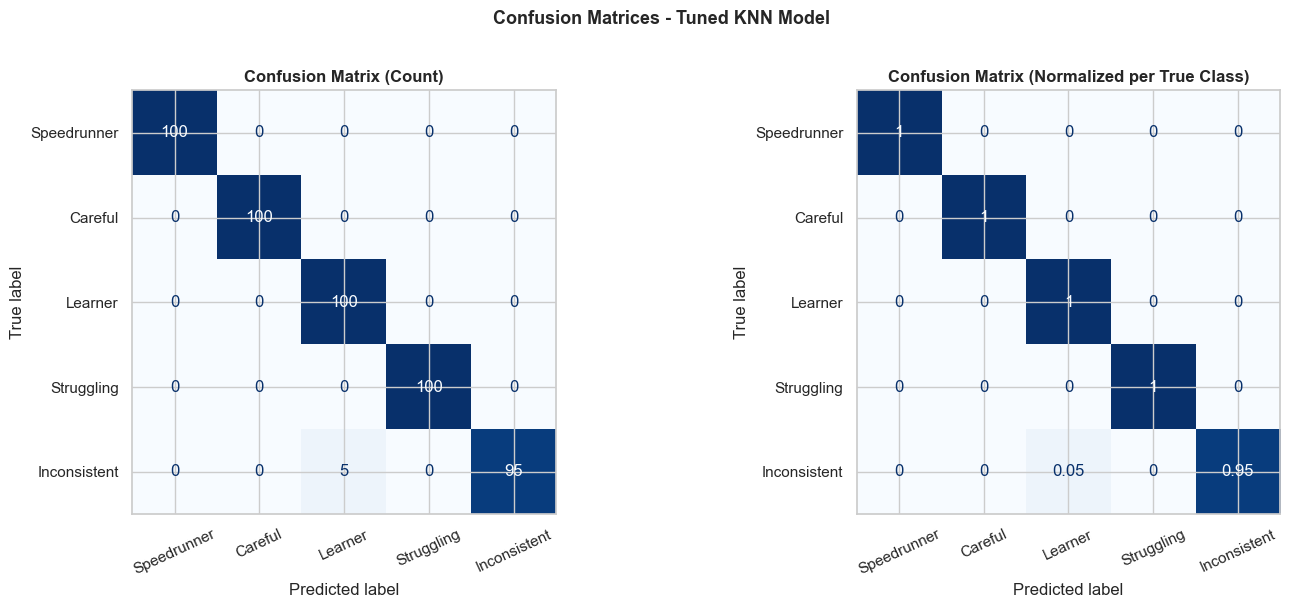

Kelas dengan misclassifikasi tertinggi:


In [12]:
cm      = confusion_matrix(y_test, y_pred)
cm_norm = confusion_matrix(y_test, y_pred, normalize="true")

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

ConfusionMatrixDisplay(cm, display_labels=PLAYER_TYPES).plot(
    ax=axes[0], colorbar=False, cmap="Blues"
)
axes[0].set_title("Confusion Matrix (Count)", fontsize=12, fontweight="bold")
axes[0].tick_params(axis="x", rotation=25)

ConfusionMatrixDisplay(cm_norm, display_labels=PLAYER_TYPES).plot(
    ax=axes[1], colorbar=False, cmap="Blues"
)
axes[1].set_title("Confusion Matrix (Normalized per True Class)", fontsize=12, fontweight="bold")
axes[1].tick_params(axis="x", rotation=25)

plt.suptitle("Confusion Matrices - Tuned KNN Model", fontsize=13, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()

print("Kelas dengan misclassifikasi tertinggi:")
for i in range(len(PLAYER_TYPES)):
    fp = cm_norm[i].copy()
    fp[i] = 0
    if fp.max() > 0.05:
        j = fp.argmax()
        print(f"  {PLAYER_TYPES[i]:<15} sering salah -> {PLAYER_TYPES[j]} ({fp[j]*100:.1f}%)")

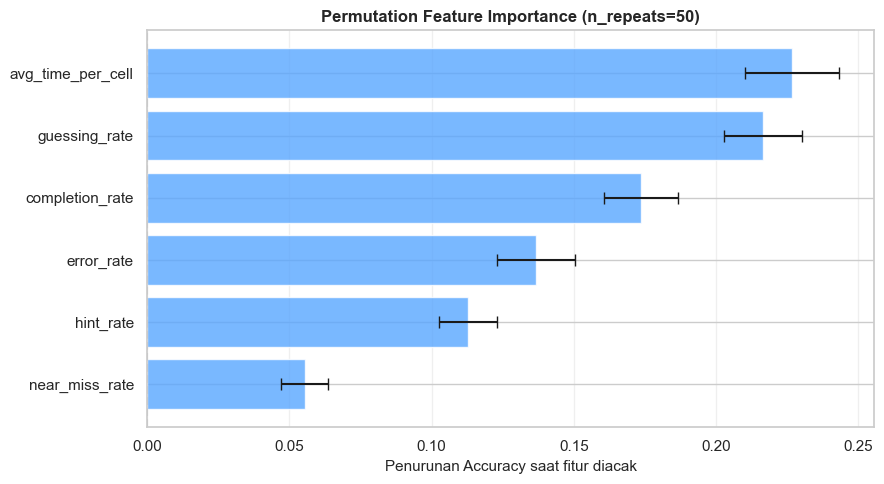

Ranking feature importance:
  avg_time_per_cell        : +0.2268 +/- 0.0165  #############################################
  guessing_rate            : +0.2163 +/- 0.0137  ###########################################
  completion_rate          : +0.1735 +/- 0.0130  ##################################
  error_rate               : +0.1367 +/- 0.0138  ###########################
  hint_rate                : +0.1128 +/- 0.0102  ######################
  near_miss_rate           : +0.0553 +/- 0.0081  ###########


In [13]:
# Permutation Importance untuk melihat seberapa besar penurunan F1 jika fitur diacak
final_scaler = grid_search.best_estimator_.named_steps["scaler"]
final_knn    = grid_search.best_estimator_.named_steps["knn"]
X_test_sc    = final_scaler.transform(X_test)

perm = permutation_importance(
    final_knn, X_test_sc, y_test,
    n_repeats=50,
    random_state=RANDOM_SEED,
    scoring="accuracy"
)

imp_df = pd.DataFrame({
    "feature":  FEATURE_NAMES,
    "mean":     perm.importances_mean,
    "std":      perm.importances_std,
}).sort_values("mean", ascending=True)

fig, ax = plt.subplots(figsize=(9, 5))
colors_bar = ["#58A6FF" if v >= 0 else "#FF7B7B" for v in imp_df["mean"]]
ax.barh(imp_df["feature"], imp_df["mean"],
        xerr=imp_df["std"], color=colors_bar, alpha=0.80, capsize=4)
ax.axvline(x=0, color="gray", linestyle="--", alpha=0.5)
ax.set_xlabel("Penurunan Accuracy saat fitur diacak", fontsize=11)
ax.set_title("Permutation Feature Importance (n_repeats=50)", fontsize=12, fontweight="bold")
ax.grid(True, axis="x", alpha=0.3)
plt.tight_layout()
plt.show()

print("Ranking feature importance:")
for _, row in imp_df.iloc[::-1].iterrows():
    bar = "#" * max(1, int(row["mean"] * 200))
    print(f"  {row['feature']:25s}: {row['mean']:+.4f} +/- {row['std']:.4f}  {bar}")

## 8. ***Robustness Test - Multi-Seed Cross Validation***

Uji stabilitas model terhadap variasi random seed CV. Model yang **robust** harus memiliki `std_across_seeds < 0.02`. Ini mensimulasikan model yang dipakai pada berbagai distribusi data pemain berbeda.

In [14]:
TEST_SEEDS = [0, 7, 13, 21, 42, 99, 123, 256, 512, 1337]
seed_accs   = []

print("=" * 50)
print("ROBUSTNESS TEST (10 Random Seeds)")
print("=" * 50)
for seed in TEST_SEEDS:
    cv_s  = StratifiedKFold(n_splits=5, shuffle=True, random_state=seed)
    scores = cross_val_score(
        grid_search.best_estimator_, X, y,
        cv=cv_s, scoring="accuracy"
    )
    seed_accs.append(scores.mean())
    print(f"  Seed {seed:5d}: F1 = {scores.mean():.4f}  +/- {scores.std():.4f}")

mean_acc = np.mean(seed_accs)
std_acc  = np.std(seed_accs)
print()
print(f"Mean F1 across seeds : {mean_acc:.4f}")
print(f"Std  F1 across seeds : {std_acc:.4f}")
print()
if std_acc < 0.01:
    print("ROBUSTNESS: Sangat stabil (std < 0.01)")
elif std_acc < 0.02:
    print("ROBUSTNESS: Stabil (std < 0.02)")
elif std_acc < 0.03:
    print("ROBUSTNESS: Cukup stabil (std < 0.03)")
else:
    print("ROBUSTNESS: Perlu perhatian (std >= 0.03), pertimbangkan lebih banyak data")

# Baseline comparison
base_seed_accs = []
for seed in TEST_SEEDS:
    cv_s = StratifiedKFold(n_splits=5, shuffle=True, random_state=seed)
    scores = cross_val_score(
        KNeighborsClassifier(n_neighbors=3, metric="euclidean"),
        X_tr_sc, y_train, cv=cv_s, scoring="accuracy"
    )
    base_seed_accs.append(scores.mean())

print()
print(f"Baseline Mean F1 across seeds : {np.mean(base_seed_accs):.4f}")
print(f"Baseline Std  F1 across seeds : {np.std(base_seed_accs):.4f}")
print(f"Improvement   : +{mean_acc - np.mean(base_seed_accs):.4f} accuracy")

ROBUSTNESS TEST (10 Random Seeds)
  Seed     0: F1 = 0.9812  +/- 0.0020
  Seed     7: F1 = 0.9832  +/- 0.0063
  Seed    13: F1 = 0.9804  +/- 0.0059
  Seed    21: F1 = 0.9812  +/- 0.0043
  Seed    42: F1 = 0.9816  +/- 0.0064
  Seed    99: F1 = 0.9804  +/- 0.0056
  Seed   123: F1 = 0.9804  +/- 0.0064
  Seed   256: F1 = 0.9816  +/- 0.0051
  Seed   512: F1 = 0.9820  +/- 0.0055
  Seed  1337: F1 = 0.9796  +/- 0.0066

Mean F1 across seeds : 0.9812
Std  F1 across seeds : 0.0010

ROBUSTNESS: Sangat stabil (std < 0.01)

Baseline Mean F1 across seeds : 0.9767
Baseline Std  F1 across seeds : 0.0014
Improvement   : +0.0045 accuracy


## 9. ***Model Comparison Summary***

In [15]:
y_pred_base_te = knn_base.predict(X_te_sc)
base_test_acc_tuned   = accuracy_score(y_test, y_pred_base_te)

summary = [
    ("Train Accuracy",     f"{base_train_acc:.4f}",
                           f"{tuned_train:.4f}",
                           f"{tuned_train - base_train_acc:+.4f}"),
    ("Test Accuracy",      f"{base_test_acc:.4f}",
                           f"{test_acc:.4f}",
                           f"{test_acc - base_test_acc:+.4f}"),
    ("Test Accuracy",      f"{base_test_acc_tuned:.4f}",
                           f"{test_acc_tuned:.4f}",
                           f"{test_acc_tuned - base_test_acc_tuned:+.4f}"),
    ("Train-Test Gap",     f"{base_train_acc - base_test_acc:.4f}",
                           f"{tuned_train - test_acc:.4f}",
                           "(lower is better)"),
    ("CV Acc Mean",         f"{cv_base_scores.mean():.4f}",
                           f"{best_cv_acc:.4f}",
                           f"{best_cv_acc - cv_base_scores.mean():+.4f}"),
    ("Robustness (std)",   f"{np.std(base_seed_accs):.4f}",
                           f"{std_acc:.4f}",
                           "(lower is better)"),
    ("k",                  "3 (fixed)",       str(best_k),       ""),
    ("metric",             "euclidean",        best_metric,       ""),
    ("weights",            "uniform",          best_weights,      ""),
]

print(f"{'Metrik':<22} {'Baseline':>14} {'Tuned':>14} {'Delta':>14}")
print("-" * 65)
for name, base_val, tuned_val, delta in summary:
    print(f"{name:<22} {base_val:>14} {tuned_val:>14} {delta:>14}")

Metrik                       Baseline          Tuned          Delta
-----------------------------------------------------------------
Train Accuracy                 0.9890         0.9790        -0.0100
Test Accuracy                  0.9860         0.9900        +0.0040
Test Accuracy                  0.9860         0.9900        +0.0040
Train-Test Gap                 0.0030        -0.0110 (lower is better)
CV Acc Mean                    0.9785         0.9805        +0.0020
Robustness (std)               0.0014         0.0010 (lower is better)
k                           3 (fixed)             15               
metric                      euclidean      euclidean               
weights                       uniform        uniform               


## 10. ***Save & Verify Model***

Scaler dan model di-extract secara terpisah dari pipeline agar bisa dipanggil individual.

In [16]:
# Extract komponen dari pipeline (sesuai format yang dipakai Sudoku.py)
final_scaler_export = grid_search.best_estimator_.named_steps["scaler"]
final_knn_export    = grid_search.best_estimator_.named_steps["knn"]
final_accuracy      = float(accuracy_score(y_test, grid_search.best_estimator_.predict(X_test)))

pkl_payload = {
    "model":    final_knn_export,
    "scaler":   final_scaler_export,
    "accuracy": final_accuracy,
    "X_syn":    X_train.tolist(),
    "y_syn":    y_train.tolist(),
    "meta": {
        "n_neighbors":   best_k,
        "metric":        best_metric,
        "weights":       best_weights,
        "cv_accuracy":   best_cv_acc,
        "test_accuracy_tuned": test_acc_tuned,
        "train_gap":     float(tuned_train - test_acc),
        "n_train":       int(X_train.shape[0]),
        "player_types":  PLAYER_TYPES,
        "feature_names": FEATURE_NAMES,
    }
}

folders = Path("Files")
folders.mkdir(parents=True, exist_ok=True)
path_folder = folders / "Player_Classifier.pkl"

with open(path_folder, "wb") as f:
    pickle.dump(pkl_payload, f, protocol=pickle.HIGHEST_PROTOCOL)

size_kb = path_folder.stat().st_size / 1024
print(f"Saved: Player_Classifier.pkl ({size_kb:.1f} kb)")
print(f"  model    : {final_knn_export}")
print(f"  scaler   : {final_scaler_export}")
print(f"  accuracy : {final_accuracy:.4f}")

Saved: Player_Classifier.pkl (259.9 kb)
  model    : KNeighborsClassifier(metric='euclidean', n_neighbors=15)
  scaler   : StandardScaler()
  accuracy : 0.9900


In [17]:
# Verifikasi load ulang
with open(path_folder, "rb") as f:
    loaded = pickle.load(f)

loaded_knn    = loaded["model"]
loaded_scaler = loaded["scaler"]

# Simulasi persis seperti PlayerMLEngine di Sudoku.py
sample_features = np.array([[
    3.5,    # avg_time_per_cell - cukup cepat
    0.03,   # error_rate        - akurat
    0.02,   # hint_rate         - mandiri
    0.95,   # completion_rate   - sering selesai
    0.30,   # near_miss_rate
    0.10    # guessing_rate
]], dtype=float)

fv_sc    = loaded_scaler.transform(sample_features)
pred_idx = int(loaded_knn.predict(fv_sc)[0])
proba    = loaded_knn.predict_proba(fv_sc)[0]

print()
print("Verifikasi prediksi (tpc=3.5s, er=3%, hr=2%, cr=95%):")
print(f"  Predicted type  : {PLAYER_TYPES[pred_idx]} (index {pred_idx})")
print(f"  Confidence      : {max(proba)*100:.1f}%")
print(f"  All probabilities:")
for pt, p in zip(PLAYER_TYPES, proba):
    bar = "|" * int(p * 40)
    print(f"    {pt:<15}: {p*100:5.1f}%  {bar}")
print()


Verifikasi prediksi (tpc=3.5s, er=3%, hr=2%, cr=95%):
  Predicted type  : Speedrunner (index 0)
  Confidence      : 100.0%
  All probabilities:
    Speedrunner    : 100.0%  ||||||||||||||||||||||||||||||||||||||||
    Careful        :   0.0%  
    Learner        :   0.0%  
    Struggling     :   0.0%  
    Inconsistent   :   0.0%  

